# K-nearest neighbor (kNN)
knn is a supervised learning algorithm that is used for classification and regression. It is a non-parametric learning method based on local similarity.

it is a lazy learning algorithm, which means that it does not build a model until it is needed.

it is also a lazy learning algorithm, which means that it does not build a model until it is needed.

it is also a lazy learning algorithm, which means that it does not build a model until it is needed.
 
KNN algorithm is a non-parametric supervised learning algorithm which uses a lazy learning algorithm. It is also a lazy learning algorithm which means that it does not build a model until it is needed.


In [1]:
# Example of KNN classifier on IRIS data using sns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# load the dataset
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# split the data into X and y
X = df.drop('species', axis=1)
y = df['species']

In [5]:
# load and fit the KNN classifier on the data 
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

# predict the spacies for a new set of menasurements
new_measurements = np.array([[5.1, 3.5, 1.4, 0.2]])
knn.predict(new_measurements)

c:\Users\nasik\miniconda3\envs\python_ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['setosa'], dtype=object)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


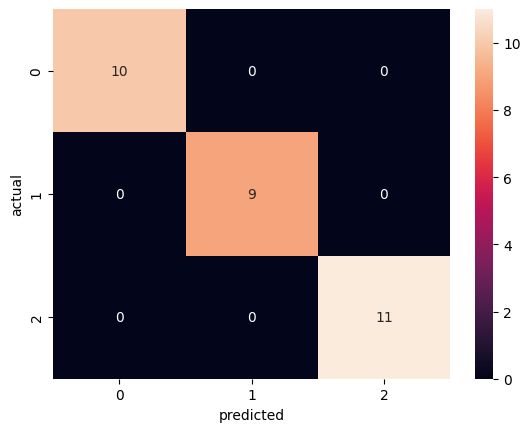

In [6]:
# train test split the data
from cycler import K
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=42)

# call the model
model = KNeighborsClassifier(n_neighbors=5)
# fit the model on the training data
model.fit(X_train, y_train)
# predict the model on the test data
y_pred = model.predict(X_test)

# evaluate the model
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

#plot the confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()


# Regression using KNN


In [7]:
# Regression problem on tips dataset 

# load the dataset
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
# split the data into X and y
X = tips.drop('tip', axis=1)
y = tips['tip']


In [11]:
# encode the categorical columns using for loop
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        X[col] = le.fit_transform(X[col])

In [12]:
# train test split the data and run the model 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)

# fit the model on the training data
model.fit(X_train, y_train) 

# predict the model on the test data
y_pred = model.predict(X_test)

# evaluate the model
from sklearn.metrics import mean_absolute_error, r2_score
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('R2 Score:', r2_score(y_test, y_pred))
print(f'RMSE: {np.sqrt(mean_absolute_error(y_test, y_pred))}')

Mean Absolute Error: 0.7262448979591837
R2 Score: 0.3294034029001649
RMSE: 0.8522000340056223


In [14]:
X_test.head()

,total_bill,sex,smoker,day,time,size
24,19.82,1,0,1,0,2
6,8.77,1,0,2,0,2
153,24.55,1,0,2,0,4
211,25.89,1,1,1,0,4
198,13.00,0,1,3,1,2


In [16]:
# predict a specific value
model.predict([[19.82, 1, 1, 1, 1, 3]])

c:\Users\nasik\miniconda3\envs\python_ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([2.844])